In [1]:
# Install required packages.
import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

# Helper function for visualization.
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

2.6.0+cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 24.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 29.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 2.9 MB/s eta 0:00:00


# 使用图神经网络进行节点分类（Node Classification with Graph Neural Networks）



这一章是如何将 **图神经网络（GNNs）应用于节点分类任务**。  
在该任务中，我们仅知道图中一小部分节点的真实标签，并希望推断出其余所有节点的标签（这属于**传导式学习（transductive learning）**）。

为演示这一过程，我们使用 `Cora` 数据集。  
这是一个**引文网络（citation network）**，其中的节点表示学术文档。

每个节点由一个 1433 维的词袋（bag-of-words）特征向量表示。  
如果两篇文档之间存在引用关系，则它们之间存在一条边。  
任务是推断每篇文档所属的类别（共有 7 类）。

该数据集最早由 [Yang 等人（2016）](https://arxiv.org/abs/1603.08861) 引入，并作为 `Planetoid` 基准套件的一部分。  
我们仍然可以借助 [PyTorch Geometric](https://github.com/rusty1s/pytorch_geometric) 简单地访问该数据集，通过以下接口实现加载：  
[`torch_geometric.datasets.Planetoid`](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets.Planetoid)

In [2]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

dataset = Planetoid(root='data/Planetoid', name='Cora', transform=NormalizeFeatures())

print()
print(f'Dataset: {dataset}:')
print('======================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

data = dataset[0]  # Get the first graph object.

print()
print(data)
print('===========================================================================================================')

# Gather some statistics about the graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Number of training nodes: {data.train_mask.sum()}')
print(f'Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')

Processing...



Dataset: Cora():
Number of graphs: 1
Number of features: 1433
Number of classes: 7

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
Number of nodes: 2708
Number of edges: 10556
Average node degree: 3.90
Number of training nodes: 140
Training node label rate: 0.05
Has isolated nodes: False
Has self-loops: False
Is undirected: True


Done!


总体来说，该数据集与我们之前使用的 [`KarateClub`](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets.KarateClub) 网络非常相似。

我们可以看到，`Cora` 网络包含 **2,708 个节点** 和 **10,556 条边**，节点的平均度约为 **3.9**。  
在训练过程中，我们仅获得了 140 个节点的真实类别信息（每个类别 20 个节点），这意味着训练集中节点标签的占比仅为 **5%**。

与 `KarateClub` 不同的是，这个图还包含两个额外的属性：`val_mask` 和 `test_mask`，它们分别指示哪些节点被用于**验证（validation）**和**测试（testing）**。

此外，我们还使用了一个 **[数据变换（transform）](https://pytorch-geometric.readthedocs.io/en/latest/notes/introduction.html#data-transforms)**，通过参数 `transform=NormalizeFeatures()` 实现。

数据变换用于在数据进入神经网络之前对其进行修改，例如进行归一化或数据增强等操作。  
在这里，我们使用 [`NormalizeFeatures`](https://pytorch-geometric.readthedocs.io/en/latest/modules/transforms.html#torch_geometric.transforms.NormalizeFeatures) 对词袋输入特征向量进行了**按行归一化（row-normalization）**。

此外，我们还可以看到，这张图是**无向图**，且**没有孤立节点**（每篇文档至少引用或被引用一次）。

## 训练一个多层感知机网络（MLP）

从理论上讲，我们应该可以**仅根据文档内容（即词袋特征）**来推断其所属类别，而不需要考虑任何图结构或节点之间的关系信息。

让我们通过构建一个简单的 **多层感知机（MLP）** 来验证这一点。  
这个 MLP 仅作用于输入的节点特征，并对所有节点共享相同的权重：

In [4]:
import torch
from torch.nn import Linear
import torch.nn.functional as F


class MLP(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(12345)
        self.lin1 = Linear(dataset.num_features, hidden_channels)
        self.lin2 = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x):
        x = self.lin1(x)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin2(x)
        return x

model = MLP(hidden_channels=16)
print(model)

MLP(
  (lin1): Linear(in_features=1433, out_features=16, bias=True)
  (lin2): Linear(in_features=16, out_features=7, bias=True)
)


这里的 MLP 由两层线性变换构成，并通过 [ReLU](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html?highlight=relu#torch.nn.ReLU) 非线性激活函数和 [Dropout](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html?highlight=dropout#torch.nn.Dropout) 进行增强。

在模型结构上，我们首先将 1433 维的输入特征向量压缩为一个较低维度的嵌入表示（`hidden_channels=16`），  
然后第二层线性变换作为分类器，将低维嵌入映射到 7 个类别中的一个。

接下来我们将按照[本教程第一部分](https://colab.research.google.com/drive/1h3-vJGRVloF5zStxL5I0rSy4ZUPNsjy8)中类似的流程来训练这个简单的 MLP 模型。  
我们仍然使用 **交叉熵损失（Cross Entropy Loss）** 和 **Adam 优化器（Adam Optimizer）**。

这一次，我们还定义了一个 **`test` 函数**，用于评估最终模型在测试集节点上的表现（这些节点在训练时是不可见的）。

In [5]:
from IPython.display import Javascript  # Restrict height of output cell.
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 300})'''))

model = MLP(hidden_channels=16)
criterion = torch.nn.CrossEntropyLoss()  # Define loss criterion.
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)  # Define optimizer.

def train():
      model.train()
      optimizer.zero_grad()  # Clear gradients.
      out = model(data.x)  # Perform a single forward pass.
      loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
      loss.backward()  # Derive gradients.
      optimizer.step()  # Update parameters based on gradients.
      return loss

def test():
      model.eval()
      out = model(data.x)
      pred = out.argmax(dim=1)  # Use the class with highest probability.
      test_correct = pred[data.test_mask] == data.y[data.test_mask]  # Check against ground-truth labels.
      test_acc = int(test_correct.sum()) / int(data.test_mask.sum())  # Derive ratio of correct predictions.
      return test_acc

for epoch in range(1, 201):
    loss = train()
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

<IPython.core.display.Javascript object>

Epoch: 001, Loss: 1.9615
Epoch: 002, Loss: 1.9557
Epoch: 003, Loss: 1.9505
Epoch: 004, Loss: 1.9423
Epoch: 005, Loss: 1.9327
Epoch: 006, Loss: 1.9279
Epoch: 007, Loss: 1.9144
Epoch: 008, Loss: 1.9087
Epoch: 009, Loss: 1.9023
Epoch: 010, Loss: 1.8893
Epoch: 011, Loss: 1.8776
Epoch: 012, Loss: 1.8594
Epoch: 013, Loss: 1.8457
Epoch: 014, Loss: 1.8365
Epoch: 015, Loss: 1.8280
Epoch: 016, Loss: 1.7965
Epoch: 017, Loss: 1.7984
Epoch: 018, Loss: 1.7832
Epoch: 019, Loss: 1.7495
Epoch: 020, Loss: 1.7441
Epoch: 021, Loss: 1.7188
Epoch: 022, Loss: 1.7124
Epoch: 023, Loss: 1.6785
Epoch: 024, Loss: 1.6660
Epoch: 025, Loss: 1.6119
Epoch: 026, Loss: 1.6236
Epoch: 027, Loss: 1.5827
Epoch: 028, Loss: 1.5784
Epoch: 029, Loss: 1.5524
Epoch: 030, Loss: 1.5020
Epoch: 031, Loss: 1.5065
Epoch: 032, Loss: 1.4742
Epoch: 033, Loss: 1.4581
Epoch: 034, Loss: 1.4246
Epoch: 035, Loss: 1.4131
Epoch: 036, Loss: 1.4112
Epoch: 037, Loss: 1.3923
Epoch: 038, Loss: 1.3055
Epoch: 039, Loss: 1.2982
Epoch: 040, Loss: 1.2543


在训练完成后，我们可以调用 `test` 函数，查看模型在未见过的标签上的表现如何。  
在这里，我们关注的指标是模型的**准确率（accuracy）**，即**被正确分类的节点数量所占的比例**：

In [6]:
test_acc = test()
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.5900


正如我们所看到的，MLP 的测试准确率只有大约 **59%**，表现相对较差。

那么，为什么 MLP 的效果不理想呢？

主要原因在于：该模型严重**过拟合（overfitting）**，这是因为它只能接触到**极少量的训练节点**，从而导致在面对未见节点时泛化能力较差。

此外，它还忽略了一个关键的建模偏置：  
> **被引用的论文往往与当前文档属于同一类别**。

这正是图神经网络（GNN）发挥作用的地方。  
GNN 能够结合图中节点之间的连接关系，从而有效提升模型的表现。


## 训练一个图神经网络（GNN）

我们可以通过将 `torch.nn.Linear` 层替换为 PyG 的 GNN 运算符，轻松地将 MLP 转换为一个图神经网络（GNN）。

延续[本教程的第一部分](https://colab.research.google.com/drive/1h3-vJGRVloF5zStxL5I0rSy4ZUPNsjy8)，我们将线性层替换为 [`GCNConv`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.conv.GCNConv) 模块。

回顾一下，**GCN 层**（来自 [Kipf 等人，2017](https://arxiv.org/abs/1609.02907)）的定义如下：

$$
\mathbf{x}_v^{(\ell + 1)} = \mathbf{W}^{(\ell + 1)} \sum_{w \in \mathcal{N}(v) \, \cup \, \{ v \}} \frac{1}{c_{w,v}} \cdot \mathbf{x}_w^{(\ell)}
$$

其中，$\mathbf{W}^{(\ell + 1)}$ 是一个可训练的权重矩阵，维度为 `[输出特征维度, 输入特征维度]`，而 $c_{w,v}$ 是每条边的固定归一化系数。

相比之下，一个普通的 `Linear` 层的计算方式如下：

$$
\mathbf{x}_v^{(\ell + 1)} = \mathbf{W}^{(\ell + 1)} \mathbf{x}_v^{(\ell)}
$$

这种计算并**不会使用邻居节点的信息**。

In [7]:
from torch_geometric.nn import GCNConv


class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(1234567)
        self.conv1 = GCNConv(dataset.num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model = GCN(hidden_channels=16)
print(model)

GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)


为了增强对比，首先可视化一下 **未训练的 GCN 网络** 所生成的节点嵌入（node embeddings）。

为了进行可视化，我们使用 [**t-SNE**](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) 将原本 7 维的节点嵌入降维到二维平面上进行展示。

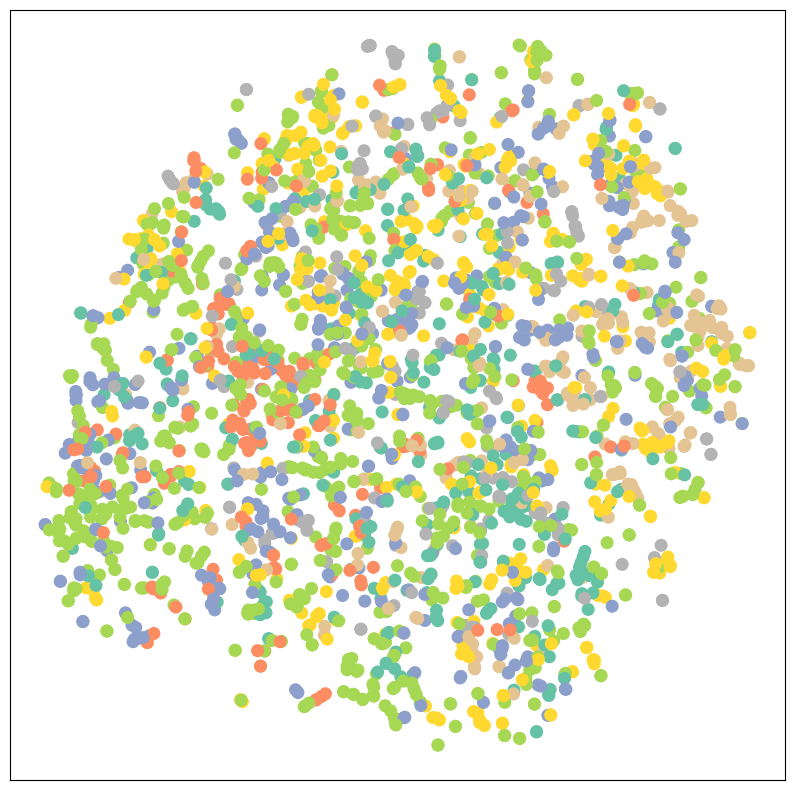

In [8]:
model = GCN(hidden_channels=16)
model.eval()

out = model(data.x, data.edge_index)
visualize(out, color=data.y)

对于这个初始化的模型，通过对模型进行训练，我们可以取得更好的效果。

训练和测试的流程与之前相同，但这一次我们将同时使用**节点特征 `x`** 和**图的连接关系 `edge_index`** 作为输入，送入我们的 GCN 模型中。

In [9]:
from IPython.display import Javascript  # Restrict height of output cell.
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 300})'''))

model = GCN(hidden_channels=16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

def train():
      model.train()
      optimizer.zero_grad()  # Clear gradients.
      out = model(data.x, data.edge_index)  # Perform a single forward pass.
      loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
      loss.backward()  # Derive gradients.
      optimizer.step()  # Update parameters based on gradients.
      return loss

def test():
      model.eval()
      out = model(data.x, data.edge_index)
      pred = out.argmax(dim=1)  # Use the class with highest probability.
      test_correct = pred[data.test_mask] == data.y[data.test_mask]  # Check against ground-truth labels.
      test_acc = int(test_correct.sum()) / int(data.test_mask.sum())  # Derive ratio of correct predictions.
      return test_acc


for epoch in range(1, 101):
    loss = train()
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

<IPython.core.display.Javascript object>

Epoch: 001, Loss: 1.9463
Epoch: 002, Loss: 1.9409
Epoch: 003, Loss: 1.9343
Epoch: 004, Loss: 1.9275
Epoch: 005, Loss: 1.9181
Epoch: 006, Loss: 1.9086
Epoch: 007, Loss: 1.9015
Epoch: 008, Loss: 1.8933
Epoch: 009, Loss: 1.8808
Epoch: 010, Loss: 1.8685
Epoch: 011, Loss: 1.8598
Epoch: 012, Loss: 1.8482
Epoch: 013, Loss: 1.8290
Epoch: 014, Loss: 1.8233
Epoch: 015, Loss: 1.8057
Epoch: 016, Loss: 1.7966
Epoch: 017, Loss: 1.7825
Epoch: 018, Loss: 1.7617
Epoch: 019, Loss: 1.7491
Epoch: 020, Loss: 1.7310
Epoch: 021, Loss: 1.7147
Epoch: 022, Loss: 1.7056
Epoch: 023, Loss: 1.6954
Epoch: 024, Loss: 1.6697
Epoch: 025, Loss: 1.6538
Epoch: 026, Loss: 1.6312
Epoch: 027, Loss: 1.6161
Epoch: 028, Loss: 1.5899
Epoch: 029, Loss: 1.5711
Epoch: 030, Loss: 1.5576
Epoch: 031, Loss: 1.5393
Epoch: 032, Loss: 1.5137
Epoch: 033, Loss: 1.4948
Epoch: 034, Loss: 1.4913
Epoch: 035, Loss: 1.4698
Epoch: 036, Loss: 1.3998
Epoch: 037, Loss: 1.4041
Epoch: 038, Loss: 1.3761
Epoch: 039, Loss: 1.3631
Epoch: 040, Loss: 1.3258


训练后，我们来看看使用GCN层的模型效果，来证明相较于MLP，GNN的优点。

In [10]:
test_acc = test()
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.8150


仅仅通过将线性层替换为 GNN 层，我们就达到了 **81.5% 的测试准确率**！  
这与 MLP 模型仅 **59% 的测试准确率** 形成了鲜明对比，说明**关系信息在提升模型性能中起到了关键作用**。

我们还可以再次验证这一点：查看 **训练后的 GCN 模型** 所生成的节点嵌入，可以发现同类别的节点在嵌入空间中的聚类效果明显更好。

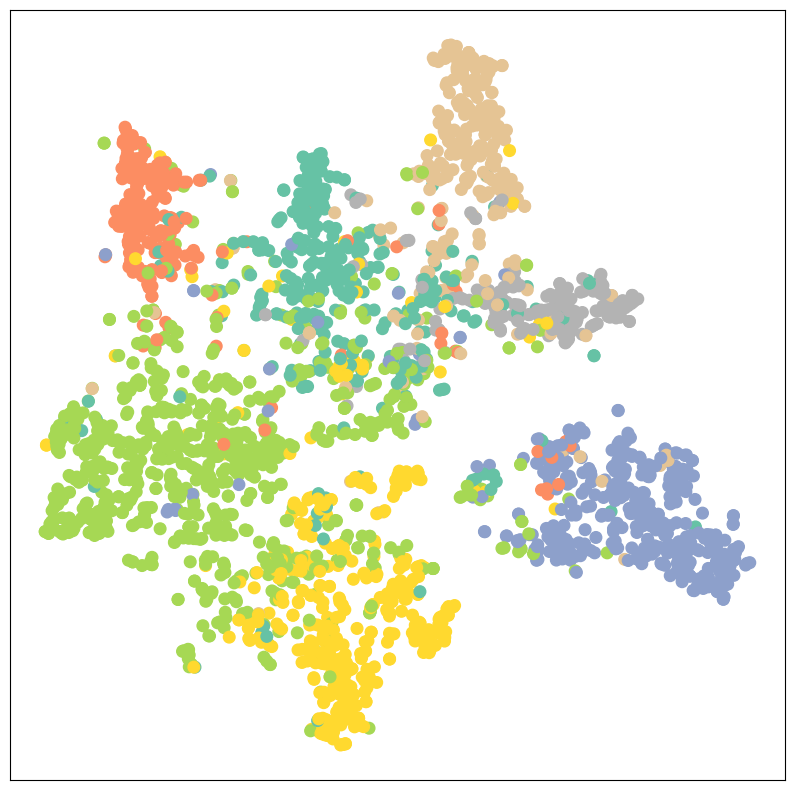

In [11]:
model.eval()

out = model(data.x, data.edge_index)
visualize(out, color=data.y)

## 总结

在本章中，学习了如何将图神经网络（GNNs）应用于现实世界中的问题，  
尤其是了解了它们如何在节点分类任务中**显著提升模型性能**。